In [2]:
import torch
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import os
import numpy as np
import pandas as pd
import pickle

from sklearn.neighbors import NearestNeighbors
from scipy.stats import gaussian_kde
from sklearn.manifold import TSNE

from utils_for_analysis import (
    calculate_ss_for_df_and_factors,
    load_df_all,
    load_df_with_budget,
    discretized_parameter_scale,
    xlabel_dict,
    ylabel_dict,
    title_fontsize,
    label_fontsize,
    tick_fontsize,
    legend_fontsize,
    original_parameter_scale,
    color_map,
    fix_ticks,
    get_labels,
    positions,
    num_muts_column_name,
    DATASET_PATHS
)

pkl_path = "/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/max_exploration_results.pkl"
with open(pkl_path, "rb") as f:
    max_exploration_results = pickle.load(f)
    
print(f"Successfully loaded {pkl_path}")



def get_relevant_columns_gfp_protgym(df, first_col, last_col):
    si = np.where(df.columns == first_col)[0][0]
    ei = np.where(df.columns == last_col)[0][0]+1
    return df.columns[si:ei]


def get_relevant_columns(dataset, df):
    cols = get_relevant_columns_gfp_protgym(df, positions[dataset][0], positions[dataset][1])
    return cols


def get_one_hot_encoding(sdf, relevant_columns):
    one_hot_encoding = pd.get_dummies(sdf[relevant_columns])
    return one_hot_encoding



# Define desired dataset order
dataset_order = ["trpb", "aamyl", "gfp","pard3", "pte", "gcn4", "nmt", "lov"]

sample_settings = {

    "gcn4": {
        "space_sizes": [3,4,5,6,7,8,9,10],
        "k_values": [5,10,20,50,100]
    },
    "pard3": {
        "space_sizes": [3,4,5,6,7,8,9,10,20],
        "k_values": [5,10,20,50,100],
    },
    "aamyl": {
        "space_sizes": [3,4,5,6,7,8,9,10,20],
        "k_values": [5,10,20,50,100]
    },
    "gfp": {
        "space_sizes": [3,4,5,6,7,8],
        "k_values": [5, 10, 50, 100, 200]
    },
    "trpb": {
        "space_sizes": [3,4,5,6,7,8,9,10],
        "k_values": [5, 10, 50, 100, 200]
    },
    "lov": {
        "space_sizes": [3,4,5,6,7,8,9,10],
        "k_values": [5, 10, 50, 100, 200, 500]
    },
    "nmt": {
        "space_sizes": [3,4,5,6,7,8,9,10,20,25],
        "k_values": [4, 5, 8, 10, 15, 20, 30, 40, 50]
    },
    "pte": {
        "space_sizes": [2,3,4],
        "k_values": [4, 5, 8, 10, 15, 20]
    }
}

Successfully loaded /home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/max_exploration_results.pkl


In [3]:
embed = False
dataset_to_use = "gcn4"
output_dir = "/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/tsne_embeddings"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "tsne_embeddings_%s.npy" % dataset_to_use)

if embed:
    embs = torch.load("/home/labs/fleishman/itayta/new_fitness_repo/fitness_learning/notebooks/data/%s/embeddings/esm_8m/embeddings.pt" % dataset_to_use)
    embs.shape
    mean_embs = embs.mean(axis=1)
    mean_embs = (mean_embs - mean_embs.mean(axis=0)) / mean_embs.std(axis=0)
    # Increase perplexity and decrease learning rate to help spread clusters apart
    tsne = TSNE(n_components=2, perplexity=60, learning_rate=50, random_state=42, init="pca")
    embs_2d = tsne.fit_transform(mean_embs)
    # Save the 2D TSNE embeddings as a numpy file
    np.save(output_path, embs_2d)
    print(f"Saved TSNE embeddings to {output_path}")

Loaded TSNE embeddings shape: (996, 2)


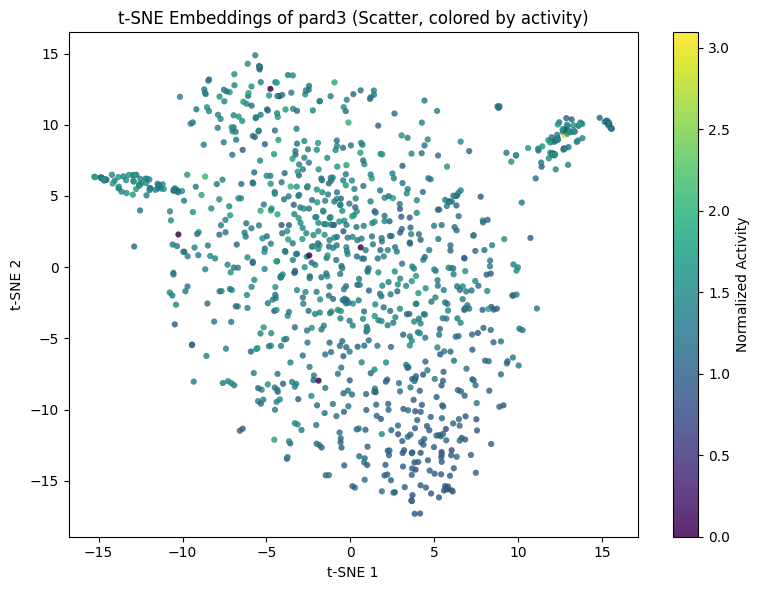

In [4]:
# Load the saved TSNE embeddings from the numpy file
loaded_tsne_embs = np.load(output_path)
print("Loaded TSNE embeddings shape:", loaded_tsne_embs.shape)

df = pd.read_csv(DATASET_PATHS[dataset_to_use])
activity = df["activity"].to_numpy()
#activity = (activity - np.nanmin(activity)) / (np.nanmax(activity) - np.nanmin(activity))

# get one-hot encoding for relevant columns
relevant_columns = get_relevant_columns(dataset_to_use, df)
ohe = get_one_hot_encoding(df, relevant_columns)
ohe_columns = ohe.columns
ohe = ohe.to_numpy().astype(int)


x = loaded_tsne_embs[:, 0]
y = loaded_tsne_embs[:, 1]
z = activity

# Remove nan entries for robustness
mask = ~np.isnan(z)
x = x[mask]
y = y[mask]
z = z[mask]

# --- 1. Scatter plot of t-SNE, colored by normalized activity ---
plt.figure(figsize=(8, 6))
scatter = plt.scatter(x, y, c=z, cmap="viridis", s=18, alpha=0.85, edgecolor='k', linewidth=0.1)
cbar = plt.colorbar(scatter, label="Normalized Activity")
plt.title("t-SNE Embeddings of pard3 (Scatter, colored by activity)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()


['142', '111', '136', '125', '103']
['132', '134', '119', '144', '126']
['110', '126', '132', '134', '101']
['101', '122', '144', '125', '101']
Best gof sum: 8
Worst gof sum: 0
PSSM gof sum: 1
Esm8m gof sum: 1
Best gof sum: 1.6067595570000002
Worst gof sum: 1.000548143
PSSM gof sum: 1.3085264405
Esm8m gof sum: 1.3942567319999999


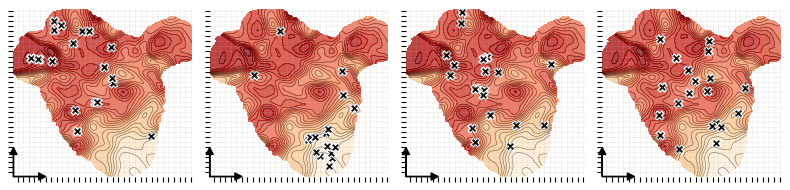

In [ ]:
def contour_tsne_values(
    tsne,
    z,
    bandwidth=1.0,
    k=8,
    support_quantile=95,
    levels=12,
    pad=0.5,
    scatter=False,
    scatter_indices=None,
    fill=True,
    text_on_contour=True,
    grid_jump=0.5,  # new arg to control jump between grid points,
    axes=None,
    ax_idx=None
):
    """
    tsne: array of shape (n, 2)
    z:    array of shape (n,)
    axes: matplotlib axes array, e.g., from plt.subplots(). If provided, use as axes.
    ax_idx: int index into axes array for which subplot to use.
    If axes is None, create a new figure.
    text_on_contour: if True, write numbers on contour lines, else just draw contours without labels
    grid_jump: Step size between grid points in each axis (default: 0.5)
    """
    x = tsne[:, 0]
    y = tsne[:, 1]
    X = np.column_stack([x, y])
    z = np.asarray(z)

    # -------------------------
    # 1. Grid -- more dense, jumps every grid_jump (default .5)
    # -------------------------
    x_grid = np.arange(x.min() - pad, x.max() + pad + grid_jump, grid_jump)
    y_grid = np.arange(y.min() - pad, y.max() + pad + grid_jump, grid_jump)
    xx, yy = np.meshgrid(x_grid, y_grid)
    grid = np.column_stack([xx.ravel(), yy.ravel()])

    # -------------------------
    # 2. Support mask:
    # keep only grid points close to real data
    # -------------------------
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)

    d_train, _ = nbrs.kneighbors(X)
    train_kdist = d_train[:, -1]

    threshold = np.percentile(train_kdist, support_quantile)

    d_grid, _ = nbrs.kneighbors(grid)
    grid_kdist = d_grid[:, -1]

    mask = grid_kdist <= threshold

    # -------------------------
    # 3. Kernel regression
    # -------------------------
    Zhat = np.full(len(grid), np.nan)

    grid_in = grid[mask]
    dx = grid_in[:, None, 0] - X[None, :, 0]
    dy = grid_in[:, None, 1] - X[None, :, 1]
    dist2 = dx**2 + dy**2

    W = np.exp(-dist2 / (2 * bandwidth**2))
    Zhat[mask] = (W @ z) / (W.sum(axis=1) + 1e-12)

    Zgrid = Zhat.reshape(xx.shape)

    # -------------------------
    # 4. Plot contours with grid in background
    # -------------------------
    if axes is not None and ax_idx is not None:
        ax = axes[ax_idx]
    elif axes is not None and isinstance(axes, dict) and ax_idx is not None:
        # If axes is a dict, index by key
        ax = axes[ax_idx]
    else:
        fig, ax = plt.subplots(figsize=(3, 3))

    import matplotlib.ticker as mticker
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.3)

    # Remove xticklabels
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # Remove box axes (all spines)
    for spine in ax.spines.values():
        spine.set_visible(False)

    if fill:
        cf = ax.contourf(xx, yy, Zgrid, levels=levels, alpha=0.75, cmap="OrRd")
        # Intentionally omitting colorbar to remove the legend

    c = ax.contour(xx, yy, Zgrid, levels=levels, colors="black", linewidths=0.4, alpha=0.5)
    if text_on_contour:
        ax.clabel(c, inline=True, fontsize=8)
    # else, don't call plt.clabel so no text goes on the contours

    if scatter:
        z_thresh = np.where(z > np.percentile(z, 90), 1, 0)
        colors = np.where(z_thresh == 1, "red", "black")
        scatter_size = 40  # Bigger scatter points
        x_scatter = X[:, 0]
        y_scatter = X[:, 1]
        if scatter_indices is None:
            ax.scatter(x_scatter[z_thresh == 1], y_scatter[z_thresh == 1], c=colors[z_thresh == 1], s=scatter_size, edgecolor="none")
        else:
            ax.scatter(
                x_scatter[scatter_indices],
                y_scatter[scatter_indices],
                c="black",
                s=scatter_size,
                edgecolor="white",
                marker="X"
            )

    # ax.set_xlabel("Sequence space 1")
    # ax.set_ylabel("Sequence space 2")
    #ax.set_title("Contour map of empirical Z over t-SNE")

    # -------------------------
    # 5. Add two connected perpendicular arrows *below* the x/y axes at the left bottom corner (origin),
    #    so they are joined at a right angle and below the axes, and are thinner.
    # -------------------------
    # Get axis limits to place arrows just below axes
    xlims = ax.get_xlim()
    ylims = ax.get_ylim()

    # Arrow origin will be slightly left and below the lower left corner
    x_offset = 0 * (xlims[1] - xlims[0])
    y_offset = 0 * (ylims[1] - ylims[0])

    # Distance arrows will be placed below/left of axes
    arrow_pad_y = 0 * (ylims[1] - ylims[0])  # vertical offset for x arrow (below axis)
    arrow_pad_x = 0 * (xlims[1] - xlims[0])  # horizontal offset for y arrow (left of axis)

    # The "joint" of the two arrows
    joint_x = xlims[0] + x_offset
    joint_y = ylims[0] - arrow_pad_y

    arr_len = 0.18 * (xlims[1] - xlims[0])

    # X arrow: from joint point horizontally right
    ax.annotate(
        "",
        xy=(joint_x + arr_len, joint_y),
        xytext=(joint_x, joint_y),
        arrowprops=dict(facecolor="black", width=0.1, headlength=5, headwidth=5),
        annotation_clip=False,
        zorder=10
    )
    # Y arrow: from joint point vertically up
    ax.annotate(
        "",
        xy=(joint_x, joint_y + arr_len),
        xytext=(joint_x, joint_y),
        arrowprops=dict(facecolor="black", width=0.1, headlength=5, headwidth=5),
        annotation_clip=False,
        zorder=10
    )
    # If not using user-provided axes, show the plot (optional -- user can control outside)
    if axes is None:
        plt.show()

# ---- New logic: two-panel plot with best/worst indices ----

S = 5
K = 20

# Example indices for "best" and "worst" (these can be set as needed)
# best = [22, 397, 566, 601, 535, 197, 647, 364, 240, 90]
# worst = [86, 661, 422, 383, 191, 326, 253, 708, 10, 694]

# best = [573, 183, 17, 283, 38]
# worst = [287, 326, 431, 346, 706]
best = [690, 138, 571, 359, 17]
worst =[500, 537, 300, 723, 383]
pssm = [116, 368, 498, 523,  13]
esm_8m = [13, 343, 729, 350, 10]

print([a.split("_")[0][1:] for a in ohe_columns[best]])
print([a.split("_")[0][1:] for a in ohe_columns[worst]])
print([a.split("_")[0][1:] for a in ohe_columns[pssm]])
print([a.split("_")[0][1:] for a in ohe_columns[esm_8m]])

indices_best = np.argsort(-ohe[:, np.array(best)].sum(axis=1))
indices_worst = np.argsort(-ohe[:, np.array(worst)].sum(axis=1))
indices_pssm = np.argsort(-ohe[:, np.array(pssm)].sum(axis=1))
indices_esm_8m = np.argsort(-ohe[:, np.array(esm_8m)].sum(axis=1))
# Print gof counts for best and worst for reporting/debug
gof = (activity > np.percentile(activity, 90))

print("Best gof sum:", sum(gof[indices_best[0:K]]))
print("Worst gof sum:", sum(gof[indices_worst[0:K]]))
print("PSSM gof sum:", sum(gof[indices_pssm[0:K]]))
print("Esm8m gof sum:", sum(gof[indices_esm_8m[0:K]]))
print("Best gof sum:", np.median(activity[indices_best[0:K]]))
print("Worst gof sum:", np.median(activity[indices_worst[0:K]]))
print("PSSM gof sum:", np.median(activity[indices_pssm[0:K]]))
print("Esm8m gof sum:", np.median(activity[indices_esm_8m[0:K]]))
fig, axes = plt.subplots(1, 4, figsize=(8, 2))


bw = 1
levels = 25
# Best
contour_tsne_values(
    loaded_tsne_embs,
    activity,
    bandwidth=bw,
    k=50,
    support_quantile=99,
    levels=levels,
    text_on_contour=False,
    scatter=True,
    scatter_indices=indices_best[0:K],
    grid_jump=0.25,
    axes=axes,
    ax_idx=0
)
#axes[0].set_title("Optimal library")

# Worst
contour_tsne_values(
    loaded_tsne_embs,
    activity,
    bandwidth=bw,
    k=50,
    support_quantile=99,
    levels=levels,
    text_on_contour=False,
    scatter=True,
    scatter_indices=indices_worst[0:K],
    grid_jump=0.25,
    axes=axes,
    ax_idx=1
)

# PSSM
contour_tsne_values(
    loaded_tsne_embs,
    activity,
    bandwidth=bw,
    k=50,
    support_quantile=99,
    levels=levels,
    text_on_contour=False,
    scatter=True,
    scatter_indices=indices_pssm[0:K],
    grid_jump=0.25,
    axes=axes,
    ax_idx=2
)

# PSSM
contour_tsne_values(
    loaded_tsne_embs,
    activity,
    bandwidth=bw,
    k=50,
    support_quantile=99,
    levels=levels,
    text_on_contour=False,
    scatter=True,
    scatter_indices=indices_esm_8m[0:K],
    grid_jump=0.25,
    axes=axes,
    ax_idx=3
)

#axes[1].set_title("Suboptimal library")

plt.tight_layout()
plt.savefig("./data/tsne_embeddings/tsne_contour_export_%s_best_worst.svg" % dataset_to_use, format="svg")
plt.show()

{'unique_gof_matrix': array([[ 3.,  5.,  9., 15., 23.],
        [ 3.,  4.,  9., 15., 19.],
        [ 2.,  3.,  7., 15., 21.],
        [ 4.,  6., 10., 13., 22.],
        [ 3.,  3.,  8., 14., 19.],
        [ 1.,  5.,  6., 13., 22.],
        [ 3.,  5.,  8., 13., 23.],
        [ 4.,  4.,  8., 12., 21.]]),
 'unique_median_activity_matrix': array([[1.75097459, 1.74032515, 1.64779548, 1.54134789, 1.43541722],
        [1.74880292, 1.64511698, 1.63012133, 1.55739681, 1.46401658],
        [1.74980424, 1.57227956, 1.58465109, 1.5705037 , 1.50036558],
        [1.79301923, 1.72594221, 1.67520742, 1.46405217, 1.44416911],
        [1.77230179, 1.5055958 , 1.60675956, 1.54605226, 1.49250869],
        [1.74980424, 1.69982793, 1.53272626, 1.4695213 , 1.4695213 ],
        [1.68058438, 1.64185623, 1.58130136, 1.45933235, 1.47328441],
        [1.75061359, 1.73375265, 1.599789  , 1.48666331, 1.454343  ]]),
 'non_unique_gof_matrix': array([[ 3.,  4.,  8., 16., 22.],
        [ 3.,  3.,  9., 15., 21.],
       

In [ ]:



# x, y are t-SNE coordinates
# z is empirical value for each point
x = loaded_tsne_embs[:, 0]
y = loaded_tsne_embs[:, 1]
z = activity

triang = mtri.Triangulation(x, y)

# Mask triangles that are too large, so holes / gaps are not bridged
triangles = triang.triangles
xtri = x[triangles]
ytri = y[triangles]

# edge lengths of each triangle
a = np.sqrt((xtri[:, 0] - xtri[:, 1])**2 + (ytri[:, 0] - ytri[:, 1])**2)
b = np.sqrt((xtri[:, 1] - xtri[:, 2])**2 + (ytri[:, 1] - ytri[:, 2])**2)
c = np.sqrt((xtri[:, 2] - xtri[:, 0])**2 + (ytri[:, 2] - ytri[:, 0])**2)

max_edge = np.maximum.reduce([a, b, c])

# tune this threshold
threshold = np.percentile(max_edge, 90)
triang.set_mask(max_edge > threshold)

plt.figure(figsize=(7, 6))
plt.scatter(x, y, c=z, s=10, alpha=0.5)
plt.tricontourf(triang, z, levels=15, alpha=0.7)
plt.tricontour(triang, z, levels=15, linewidths=0.8)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Empirical Z over t-SNE")
plt.colorbar(label="Z")
plt.show()